# Notebook 04 - Framing Detection

**Method:** Canny Edge Detection + Contour Aspect Ratio

**How it works:**
1. Apply Gaussian blur to reduce noise
2. Run Canny edge detector
3. Find all contours
4. Take the largest contour (= the document)
5. Get its bounding rectangle
6. **Compute aspect ratio (width/height) - valid range: 1.3 to 2.0**

**Why aspect ratio?** A properly framed UK passport in landscape should have width > height, roughly 1.4–1.6.

**Research:** Scanbot Document Edge Detection (2025)

**Speed:** ~8ms per image on CPU

In [1]:
import sys
sys.path.insert(0, '..')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.framing import compute_aspect_ratio, is_framing_ok, get_framing_label
from src.config  import DATASET_ROOT, IMAGE_EXTENSIONS, ASPECT_MIN, ASPECT_MAX, CANNY_LOW, CANNY_HIGH

## 1. Visualise Canny Edges + Contour

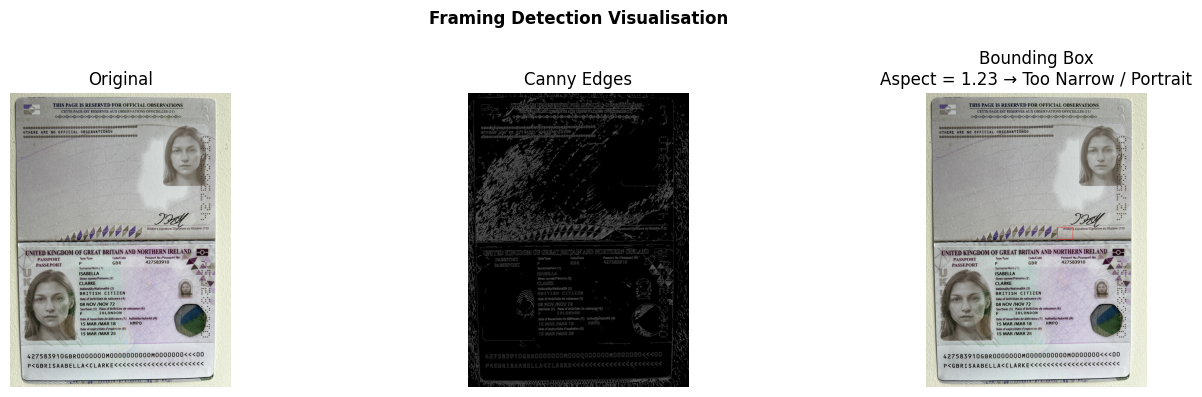

In [2]:
all_images = [p for p in Path(DATASET_ROOT).rglob('*') if p.suffix.lower() in IMAGE_EXTENSIONS]
img_path   = all_images[0]

img  = cv2.imread(str(img_path))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Edge detection
blurred = cv2.GaussianBlur(gray, (5,5), 0)
edges   = cv2.Canny(blurred, CANNY_LOW, CANNY_HIGH)

# Contours
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_contour = cv2.cvtColor(img.copy(), cv2.COLOR_BGR2RGB)

aspect, (x, y, w, h) = compute_aspect_ratio(gray)
cv2.rectangle(img_contour, (x, y), (x+w, y+h), (255, 0, 0), 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edges')
axes[2].imshow(img_contour)
axes[2].set_title(f'Bounding Box\nAspect = {aspect:.2f} → {get_framing_label(aspect)}')

for ax in axes: ax.axis('off')
plt.suptitle('Framing Detection Visualisation', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Aspect Ratio Distribution Across Dataset

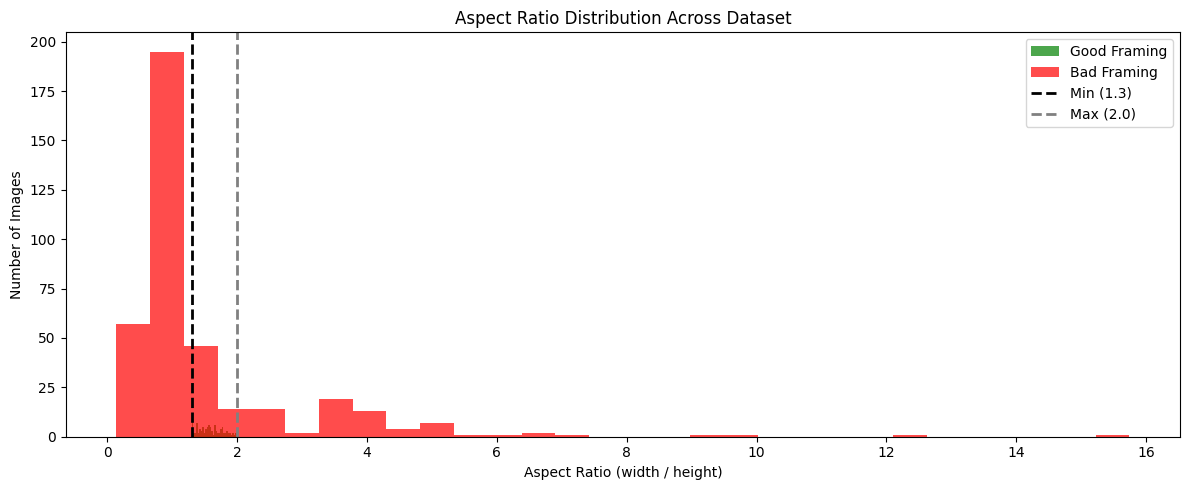

Good framing: 100 (20%)
Bad framing:  380  (79%)


In [3]:
aspects = []
frame_ok = []

for img_path in all_images:
    img = cv2.imread(str(img_path))
    if img is None: continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    aspect, ok = is_framing_ok(gray)
    if aspect > 0:
        aspects.append(aspect)
        frame_ok.append(ok)

good_aspects = [a for a, ok in zip(aspects, frame_ok) if ok]
bad_aspects  = [a for a, ok in zip(aspects, frame_ok) if not ok]

plt.figure(figsize=(12, 5))
plt.hist(good_aspects, bins=30, alpha=0.7, color='green',  label='Good Framing')
plt.hist(bad_aspects,  bins=30, alpha=0.7, color='red',    label='Bad Framing')
plt.axvline(ASPECT_MIN, color='black', linestyle='--', linewidth=2, label=f'Min ({ASPECT_MIN})')
plt.axvline(ASPECT_MAX, color='gray',  linestyle='--', linewidth=2, label=f'Max ({ASPECT_MAX})')
plt.xlabel('Aspect Ratio (width / height)')
plt.ylabel('Number of Images')
plt.title('Aspect Ratio Distribution Across Dataset')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Good framing: {len(good_aspects)} ({100*len(good_aspects)//len(aspects)}%)')
print(f'Bad framing:  {len(bad_aspects)}  ({100*len(bad_aspects)//len(aspects)}%)')

## 3. Which Angle Has Worst Framing?

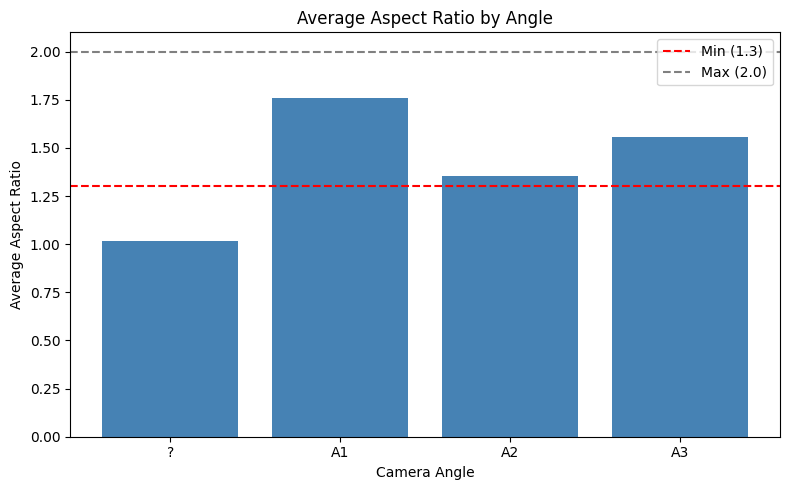

In [4]:
from collections import defaultdict
from src.parser import parse_filename

angle_aspects = defaultdict(list)

for img_path in all_images:
    img = cv2.imread(str(img_path))
    if img is None: continue
    gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    aspect, _ = compute_aspect_ratio(gray)
    if aspect > 0:
        meta = parse_filename(img_path.name)
        angle_aspects[meta['angle']].append(aspect)

avg_aspect = {k: np.mean(v) for k, v in sorted(angle_aspects.items())}

plt.figure(figsize=(8, 5))
plt.bar(avg_aspect.keys(), avg_aspect.values(), color='steelblue')
plt.axhline(ASPECT_MIN, color='red',  linestyle='--', label=f'Min ({ASPECT_MIN})')
plt.axhline(ASPECT_MAX, color='gray', linestyle='--', label=f'Max ({ASPECT_MAX})')
plt.xlabel('Camera Angle')
plt.ylabel('Average Aspect Ratio')
plt.title('Average Aspect Ratio by Angle')
plt.legend()
plt.tight_layout()
plt.show()